In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [7]:
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [8]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [9]:
x_val = x_train[:10000]
y_val = y_train[:10000]

x_train = x_train[10000:]
y_train = y_train[10000:]

In [10]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.expand_dims(image, -1)  # (28,28) → (28,28,1)
    return image, label

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

train_ds = train_ds.map(preprocess).shuffle(10000).batch(64).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(64).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(64).prefetch(AUTOTUNE)

In [12]:
for images, labels in train_ds.take(1):
    print(images.shape)

(64, 28, 28, 1)


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

In [14]:
from tensorflow.keras import layers, regularizers, Model

inputs = layers.Input(shape=(28, 28, 1))

x = data_augmentation(inputs)

# Block 1
x = layers.Conv2D(64, 3, padding='same',
                  kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.15)(x)

# Block 2
x = layers.Conv2D(128, 3, padding='same',
                  kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.2)(x)

# Block 3
x = layers.Conv2D(256, 3, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

In [15]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        save_best_only=True
    )
]

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,026 (1.43 MB)

 Trainable params: 373,130 (1.42 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.6793 - loss: 0.9115 - val_accuracy: 0.7401 - val_loss: 0.7739 - learning_rate: 0.0010
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8048 - loss: 0.5575 - val_accuracy: 0.7632 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8241 - loss: 0.4981 - val_accuracy: 0.7646 - val_loss: 0.6803 - learning_rate: 0.0010
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8343 - loss: 0.4738 - val_accuracy: 0.7414 - val_loss: 0.7136 - learning_rate: 0.0010
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8425 - loss: 0.4467 - val_accuracy: 0.8502 - val_loss: 0.4507 - learning_rate: 0.0010
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8500 - loss: 0.4318 - val_accuracy: 0.8317 - val_loss: 0.4761 - learning_rate: 0.0010
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8541 - l

In [21]:
import numpy as np

import numpy as np

def smooth_curve(points, factor=0.8):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

train_loss_smooth = smooth_curve(history.history['loss'])
val_loss_smooth = smooth_curve(history.history['val_loss'])

train_acc_smooth = smooth_curve(history.history['accuracy'])
val_acc_smooth = smooth_curve(history.history['val_accuracy'])

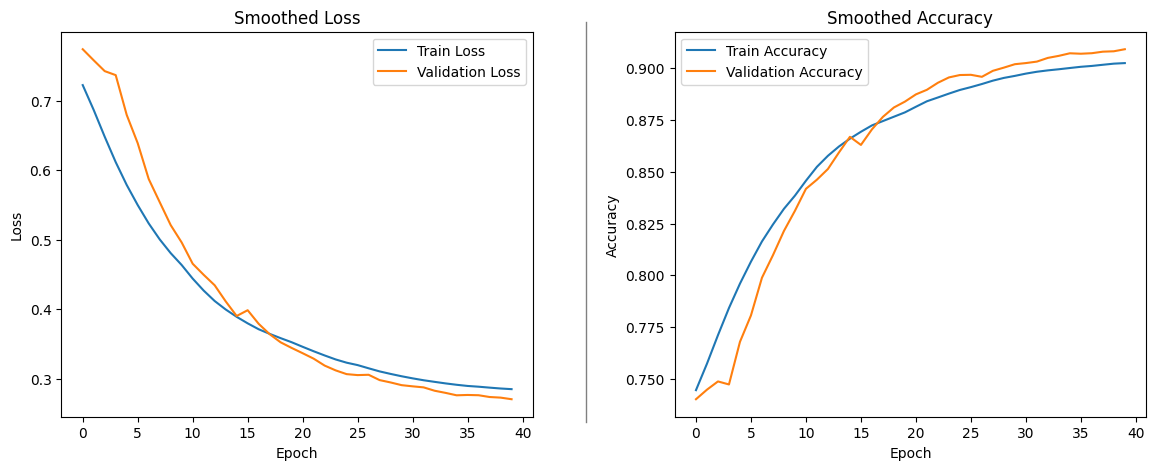

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ----- Loss -----
ax[0].plot(train_loss_smooth, label='Train Loss')
ax[0].plot(val_loss_smooth, label='Validation Loss')
ax[0].set_title("Smoothed Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# ----- Accuracy -----
ax[1].plot(train_acc_smooth, label='Train Accuracy')
ax[1].plot(val_acc_smooth, label='Validation Accuracy')
ax[1].set_title("Smoothed Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

fig.add_artist(plt.Line2D([0.5, 0.5], [0.1, 0.9],
                          transform=fig.transFigure,
                          color="gray", linewidth=1))
plt.subplots_adjust(wspace=0.3)
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2170 - loss: 762.1441
Test Accuracy: 0.20890000462532043


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


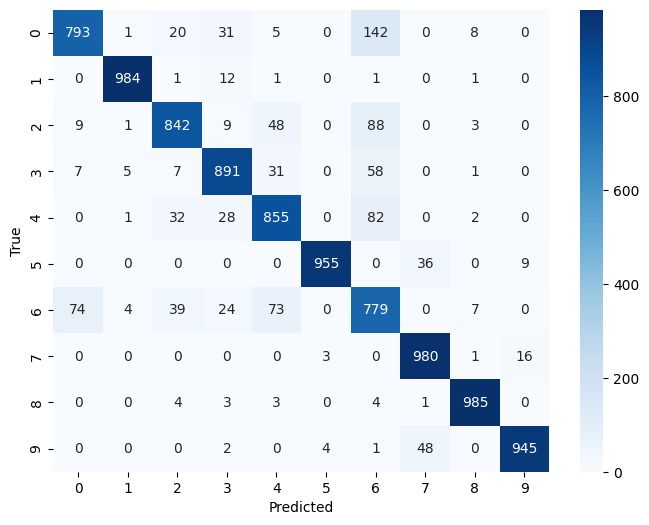

In [24]:
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()